# Human Standard Normative Divergence Calculator

Calculates the divergence between from a human standard normative (HSN) baseline

## Setup

In [1]:
!uv sync --extra analysis

Resolved 219 packages in 1ms
Audited 181 packages in 28ms


In [2]:
%load_ext autoreload
%autoreload 2

In [11]:
import json
import pandas as pd
from analysis.helpers import display_pretty, message
from itables import show
from pathlib import Path

In [4]:
with open("hsn-abilities.json", "r") as f:
    data = json.load(f)

rows = []
for category, items in data.items():
    for name, description in items.items():
        rows.append({"category": category, "assumption": name, "description": description})
hsn_abilities_df = pd.DataFrame(rows)

### Visually Inspection of HSN and Character Abilities

In [5]:
show(
    hsn_abilities_df,
    scrollY="500px",
    scrollX=True,
    paging=True,
    pageLength=25,
    columnDefs=[{"className": "dt-left", "targets": "_all"}],
)

Loading ITables v2.7.0 from the internet... (need help?)


In [6]:
CHARACTERS_JSON = "../../database_seeds/dev/characters.json"

with open(CHARACTERS_JSON, "r") as f:
    characters = json.load(f)

character_rows = []
ability_rows = []

for c in characters:
    character_rows.append(
        {
            "hid": c.get("hid"),
            "short_description": c.get("short_description"),
            "inclusion_reason": c.get("inclusion_reason"),
            "long_description": c.get("long_description"),
            "common_descriptors": ", ".join(c.get("common_descriptors") or []),
            "anthronormal_divergence": c.get("anthronormal_divergence"),
            "interaction_examples": c.get("interaction_examples"),
        }
    )

    for ability_category, items in (c.get("abilities") or {}).items():
        for item in items:
            ability_rows.append(
                {
                    "hid": c.get("hid"),
                    "ability_category": ability_category,
                    "ability": item,
                }
            )

In [7]:
characters_df = pd.DataFrame(character_rows)
characters_abilities_df = pd.DataFrame(ability_rows)

In [8]:
show(
    characters_abilities_df,
    scrollY="500px",
    scrollX=True,
    paging=True,
    pageLength=25,
    columnDefs=[{"className": "dt-left", "targets": "_all"}],
)

Loading ITables v2.7.0 from the internet... (need help?)


## Calculation

Evaluate for each character whether for each HSN ability they are normative or divergent.

- uses LLM evaluation

In [12]:
from helpers import build_hsn_divergence_df

RESULTS_DIR = Path("results")
LATEST_PATH = RESULTS_DIR / "hsn_divergence_results_latest.csv"

RESULTS_DIR.mkdir(exist_ok=True)

hsn_divergence_df = None

if LATEST_PATH.exists():
    print(f"Existing results found: {LATEST_PATH}")
    choice = input("Load existing results instead of recomputing? [y/N]: ").strip().lower()

    if choice == "y":
        print("Loading existing results...")
        hsn_divergence_df = pd.read_csv(LATEST_PATH)
    else:
        print("Recomputing divergence classifications...")
else:
    print("No existing results found. Computing classifications...")

if hsn_divergence_df is None:
    hsn_divergence_df = build_hsn_divergence_df(
        characters_df=characters_df,
        characters_abilities_df=characters_abilities_df,
        hsn_abilities_df=hsn_abilities_df,
    )

    ts = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")

    timestamped_path = RESULTS_DIR / f"hsn_divergence_results_{ts}.csv"

    # save historical snapshot
    hsn_divergence_df.to_csv(timestamped_path, index=False)

    # update latest pointer
    hsn_divergence_df.to_csv(LATEST_PATH, index=False)

    print(f"Saved results snapshot: {timestamped_path}")
    print(f"Updated latest results: {LATEST_PATH}")

No existing results found. Computing classifications...
Saved results snapshot: results/hsn_divergence_results_2026-03-06_17-16-38.csv
Updated latest results: results/hsn_divergence_results_latest.csv


### Visual Inspection of LLM Divergence Classifications

In [14]:
show(
    hsn_divergence_df,
    scrollY="500px",
    scrollX=True,
    paging=True,
    pageLength=25,
    columnDefs=[{"className": "dt-left", "targets": "_all"}],
)

Loading ITables v2.7.0 from the internet... (need help?)


## Results

### Divergence Score Ranking & Distribution

Score ranking shows which characters diverge most from the HSN baseline by plotting a bar chart of divergence score (divergent abilities ÷ total abilities) for each character, allowing characters to be ranked from most normative to most divergent.

The distribution shows how many characters fall into each divergence range using a histogram of divergence scores across all characters.

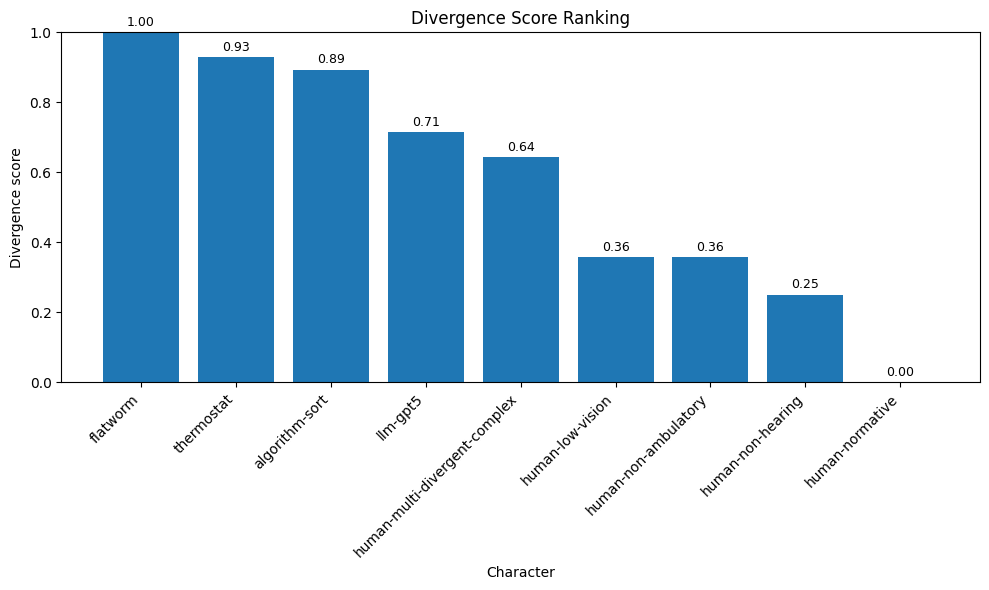

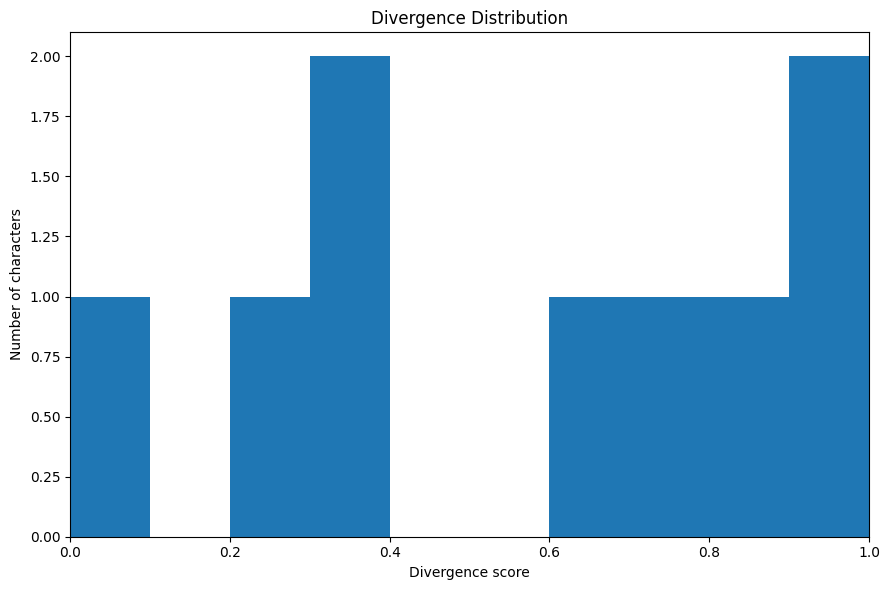

,hid,divergent_count,total_count,divergence_score
0,algorithm-sort,25,28,0.892857
1,flatworm,28,28,1.000000
2,human-low-vision,10,28,0.357143
3,human-multi-divergent-complex,18,28,0.642857
4,human-non-ambulatory,10,28,0.357143
5,human-non-hearing,7,28,0.250000
6,human-normative,0,28,0.000000
7,llm-gpt5,20,28,0.714286
8,thermostat,26,28,0.928571


In [20]:
from helpers import plot_divergence_score_ranking, plot_divergence_distribution

plot_divergence_score_ranking(hsn_divergence_df)
plot_divergence_distribution(hsn_divergence_df)

### Character x HSN Ability Divergence Map

Shows which HSN assumptions each character satisfies or violates using a heatmap where rows are characters, columns are HSN abilities, and color encodes normative vs divergent.

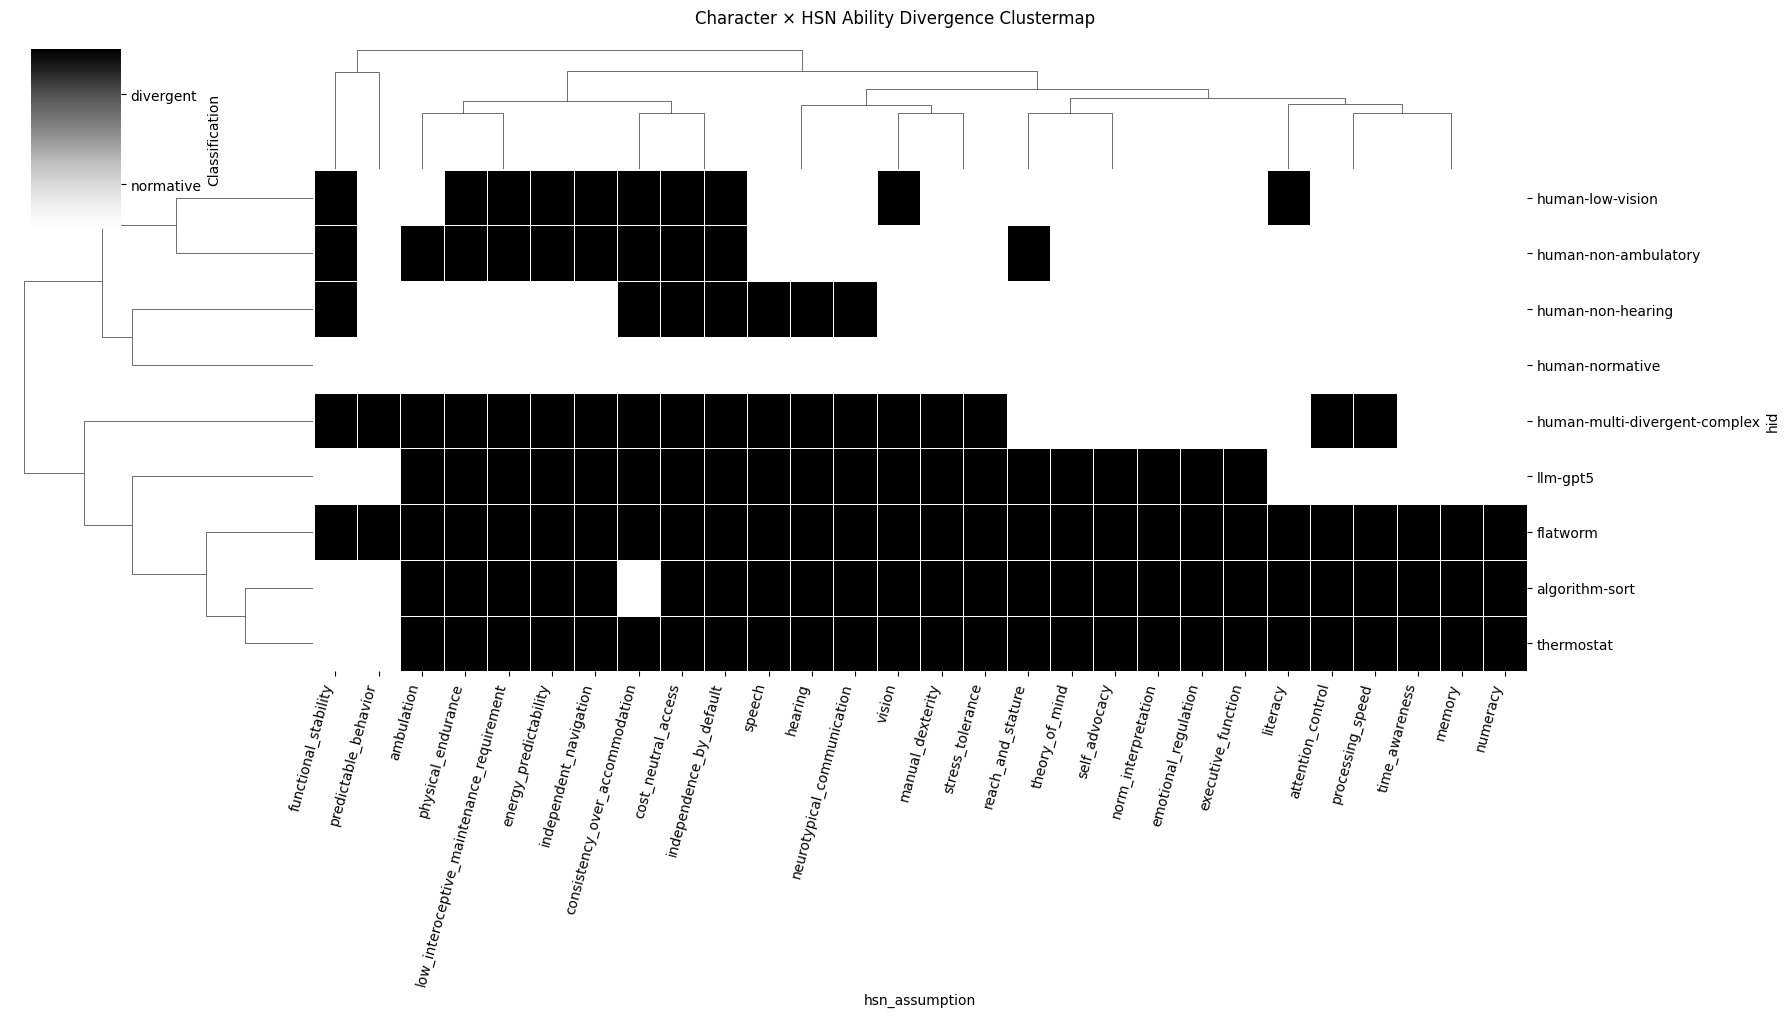

In [28]:
from helpers import plot_character_hsn_ability_clustermap

ability_heatmap_matrix = plot_character_hsn_ability_clustermap(hsn_divergence_df)

### Character × Category Divergence Heatmap

Shows how strongly each character diverges within each category of HSN assumptions using a heatmap where rows are characters, columns are HSN categories, and cell values represent the proportion of divergent abilities within that category.

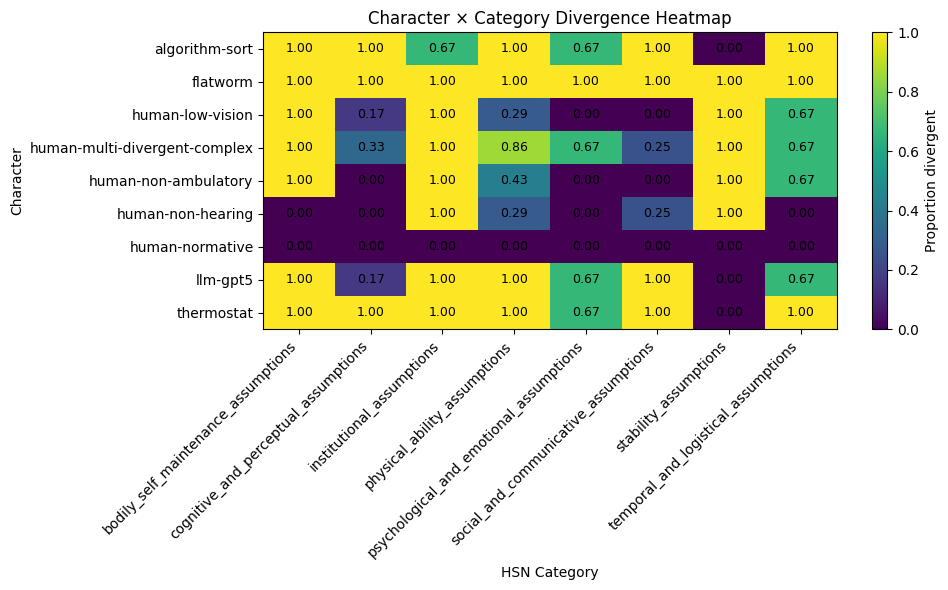

In [29]:
from helpers import plot_character_category_divergence_heatmap

character_category_heatmap_df = plot_character_category_divergence_heatmap(hsn_divergence_df)

### Most Violated HSN Assumptions

Shows which baseline assumptions are most frequently violated across characters using a bar chart counting how many characters are marked divergent for each HSN assumption.

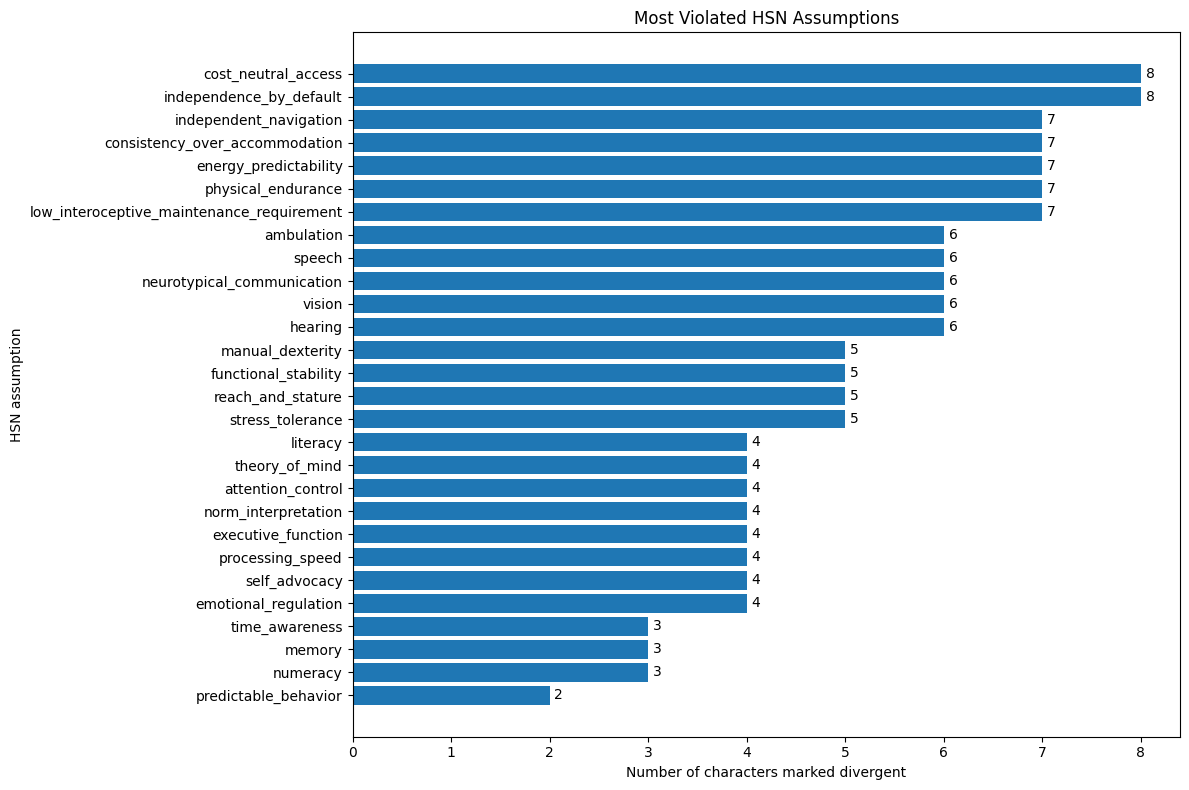

In [30]:
from helpers import plot_most_violated_hsn_assumptions

most_violated_df = plot_most_violated_hsn_assumptions(hsn_divergence_df)

### Character Divergence Fingerprint

Shows the pattern of divergence for an individual character across ability categories using a radar/spider chart where axes represent HSN categories and values represent divergence within each category.

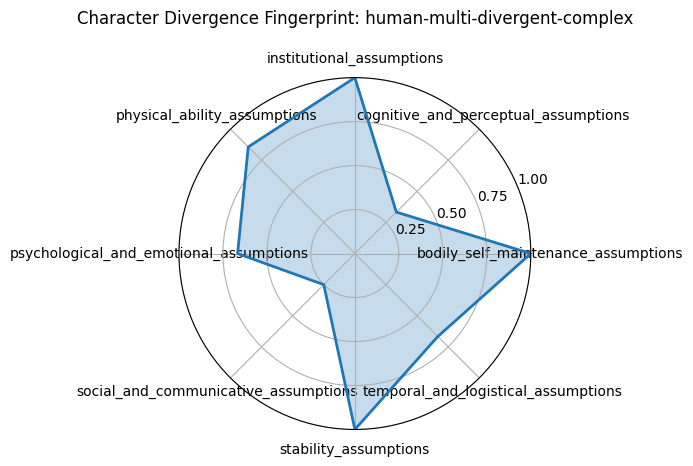

In [32]:
from helpers import plot_character_divergence_fingerprint

fingerprint_df = plot_character_divergence_fingerprint(hsn_divergence_df, hid="human-multi-divergent-complex")

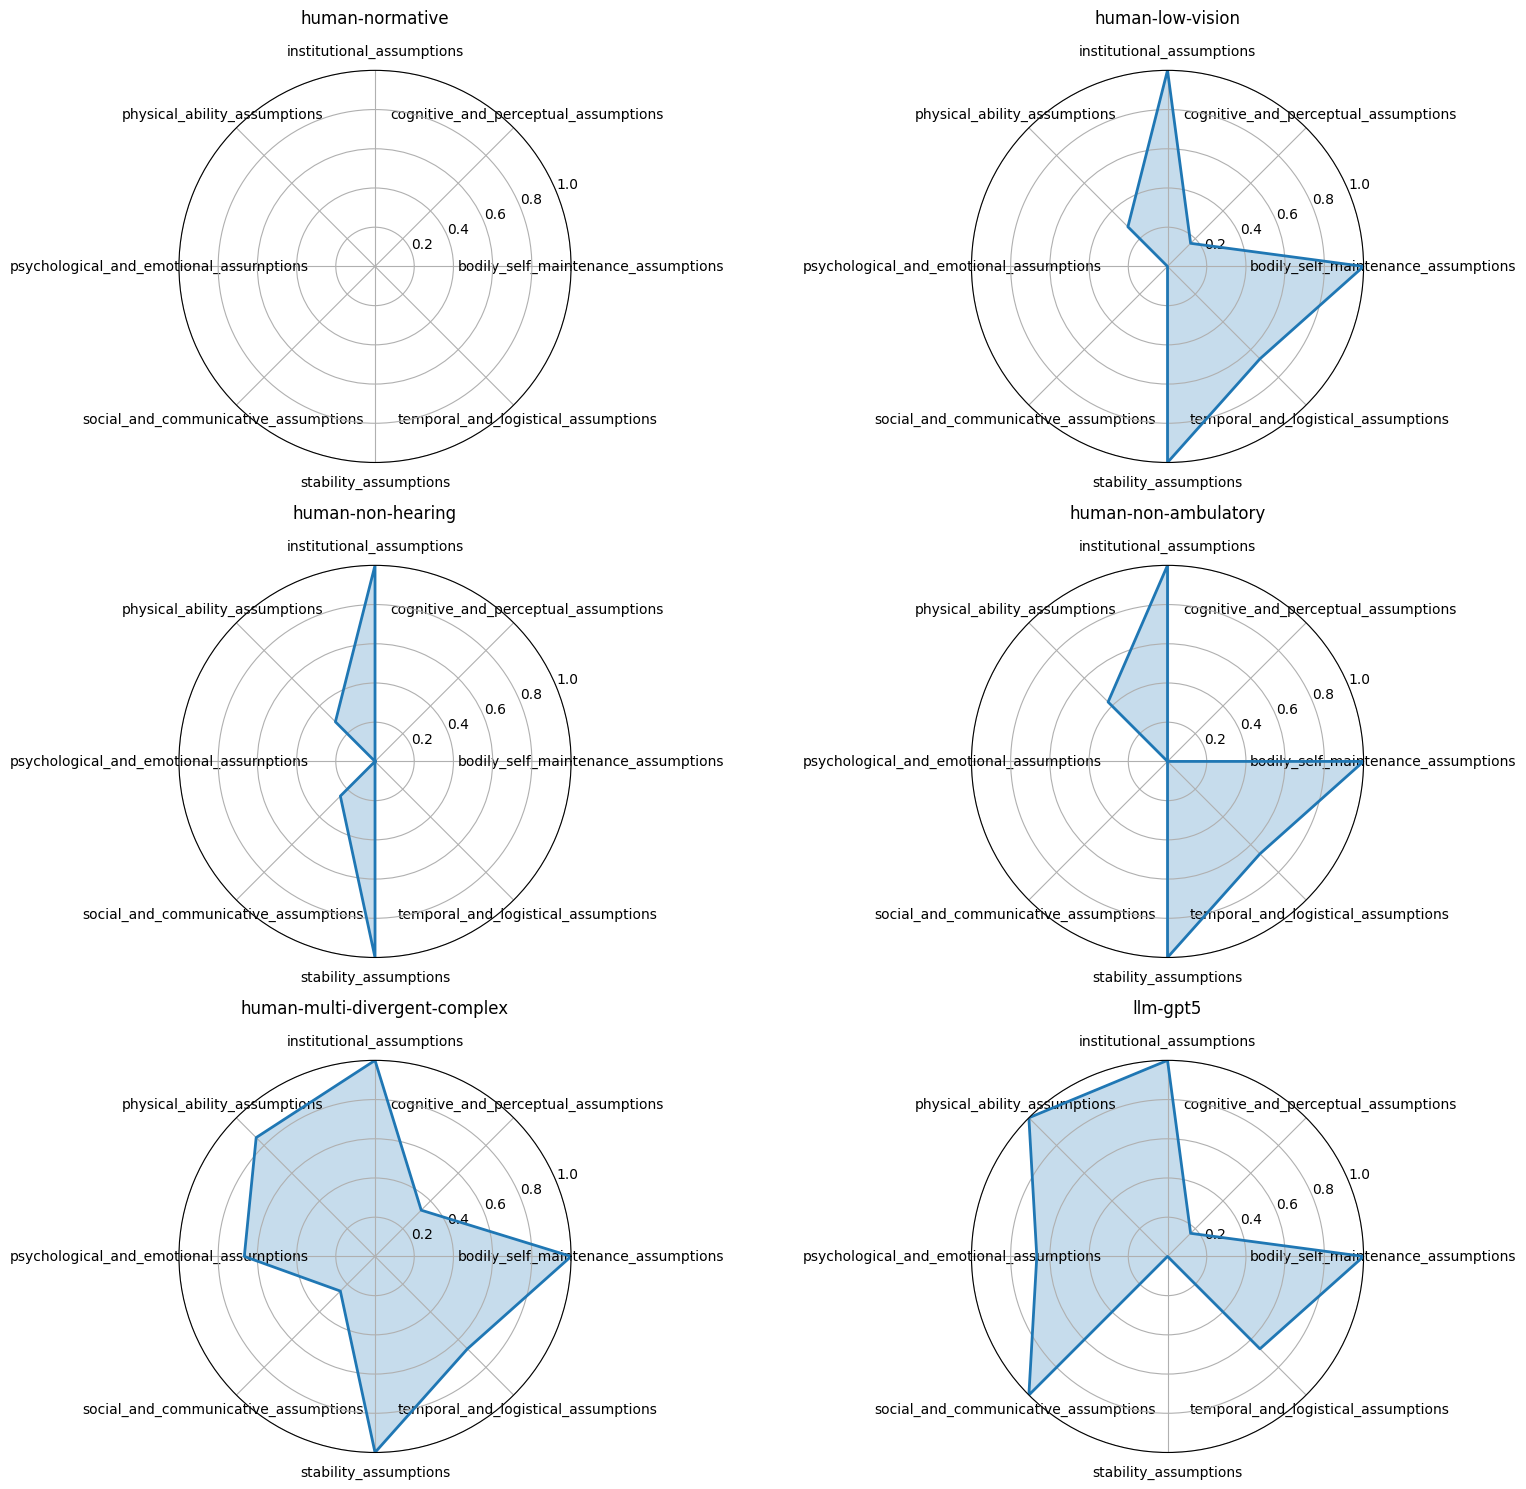

{'human-normative':                               hsn_category  divergent_count  total_count  \
 0      bodily_self_maintenance_assumptions                0            1   
 1     cognitive_and_perceptual_assumptions                0            6   
 2                institutional_assumptions                0            3   
 3             physical_ability_assumptions                0            7   
 4  psychological_and_emotional_assumptions                0            3   
 5     social_and_communicative_assumptions                0            4   
 6                    stability_assumptions                0            1   
 7      temporal_and_logistical_assumptions                0            3   
 
    divergence_rate  
 0              0.0  
 1              0.0  
 2              0.0  
 3              0.0  
 4              0.0  
 5              0.0  
 6              0.0  
 7              0.0  ,
 'human-low-vision':                               hsn_category  divergent_count  total

In [34]:
from helpers import plot_character_divergence_fingerprints

plot_character_divergence_fingerprints(
    hsn_divergence_df,
    hids=[
        "human-normative",
        "human-low-vision",
        "human-non-hearing",
        "human-non-ambulatory",
        "human-multi-divergent-complex",
        "llm-gpt5",
    ],
    figsize_per_row=(8, 5),
)

### Divergence Reason Explorer

Shows why characters diverge from specific HSN assumptions using a structured table or interactive filter displaying the LLM-generated explanations associated with each divergence classification.

In [ ]:
show(
    hsn_divergence_df[hsn_divergence_df["score"] == "divergent"],
    scrollY="500px",
    scrollX=True,
    paging=True,
    pageLength=25,
)

Loading ITables v2.7.0 from the internet... (need help?)


## Conclusion